# Практическое задание: разведочный анализ данных

Мы будем работать с датасетом про бриллианты - в нем содержатся их различные характеристики, а также стоимость.

## Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# DIAMONDS_DATASET = "https://github.com/dacourses/datasets/raw/refs/heads/main/diamonds.csv"
DIAMONDS_DATASET = "content/diamonds.csv"

In [3]:
df = pd.read_csv(DIAMONDS_DATASET)

## Описание данных

* `carat` - число каратов бриллианта
* `cut` - огранка бриллианта
* `color` - цвет бриллианта
* `clarity` - прозрачность бриллианта
* `depth` - глубина бриллианта
* `table` - платформа бриллианта (грань, которую можно увидеть, если смотреть на камень лицевой стороной вверх)
* `price` - цена бриллианта
* `x` - размер бриллианта по оси x
* `y` - размер бриллианта по оси y
* `z` - размер бриллианта по оси z

## Задание 1

Выведите на экран:
* первые 10 строк таблицы
* последние 5 строк таблицы
* 3 случайных строки таблицы

In [4]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,'x','y','z'
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75
5,NaN,Very Good,J,VVS2,62.8,57.0,336.0,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336.0,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337.0,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337.0,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338.0,4.00,4.05,2.39


In [5]:
df.tail(5)

,carat,cut,color,clarity,depth,table,price,'x','y','z'
53935,0.72,Ideal,D,SI1,60.8,57.0,2757.0,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757.0,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757.0,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757.0,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757.0,5.83,5.87,3.64


In [6]:
df.sample(3)

,carat,cut,color,clarity,depth,table,price,'x','y','z'
8504,1.17,Premium,I,SI2,62.7,57.0,4423.0,6.77,6.69,4.22
29168,0.33,Very Good,F,VVS2,63.5,54.0,694.0,4.42,4.37,2.79
3505,0.76,Ideal,D,VS2,61.8,55.0,3401.0,5.85,5.89,3.63


## Исследование данных

## Задание 2

Выведите на экран:
* размер датасета
* основные числовые характеристики столбцов (min, max, median и тд) - желательно одной командой
* основные числовые характеристики категориальных столбцов

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53442.0,0.797561,0.473534,0.2,0.40,0.70,1.04,5.01
depth,52950.0,61.749422,1.431558,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
'x',53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
'y',53935.0,5.734469,1.142125,0.0,4.72,5.71,6.54,58.90
'z',53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


Удалим дубликаты

In [8]:
df.duplicated().sum()

135

In [9]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,'x','y','z'
1005,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105.0,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919.0,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093.0,5.17,5.19,3.17
49557,0.71,Good,F,SI2,64.1,60.0,2130.0,0.00,0.00,0.00
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203.0,5.19,5.17,3.17


In [10]:
df.drop_duplicates(inplace=True)
df.shape

(53805, 10)

In [11]:
df.reset_index(inplace=True, drop=True)
df.head()

,carat,cut,color,clarity,depth,table,price,'x','y','z'
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


## Работа с пропущенными значениями

Стратегии заполнения пропусков:

* если пропусков очень мало (~меньше процента) - строки с пропусками можно удалить или заполнить средним/медианой

* если пропусков мало (~5-10%) - их можно заполнить (средним, медианой, уникальным значением, самым популярным значением, спрогнозировать)

* если пропусков много - можно удалить столбец

* можно пытаться предсказывать пропуски моделью

## Задание 3

Выясните, есть ли в данных пропуски?

In [12]:
df.isna().sum()

carat      498
cut          0
color        0
clarity      0
depth      990
table        0
price        0
'x'          0
'y'          5
'z'          0
dtype: int64

## Задание 4

Заполните пропуски:

* в столбце `carat` - медианным значением
* в столбце `depth` - медианным значением

In [13]:
cols_to_fill = ['carat', 'depth']

df[cols_to_fill] = df[cols_to_fill].fillna(df[cols_to_fill].median())

In [14]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
'x'        0
'y'        5
'z'        0
dtype: int64

## Однофакторный анализ

### Число карат

* мелкие — массой до 0,30 карат (не включительно);
* средние — массой от 0,30 до 1 карат (не включительно);
* крупные – 1 карат и выше, называют солитеры.


Небольшие бриллианты различного размера, полученные при огранке алмаза, и весящие каждый в отдельности менее 0,25 карат, называют *melee (мили)*. Полученные таким же путем более крупные бриллианты различного размера называют *melange (меланж)*.


Бриллианты более 6 карат обычно продаются c аукционов.


Алмазам и бриллиантам более 25 карат присваивают собственные имена.

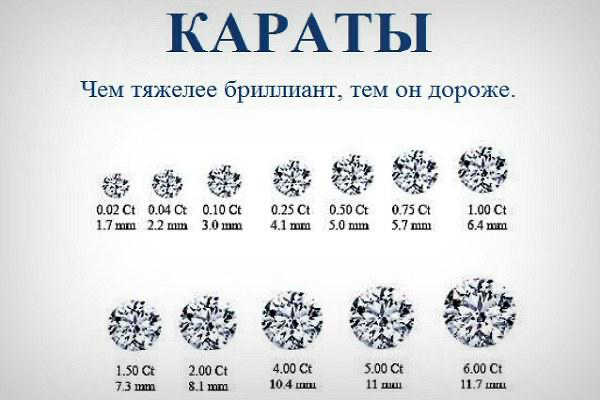

## Задание 5

Постройте гистограмму распределения столбца `carat`.

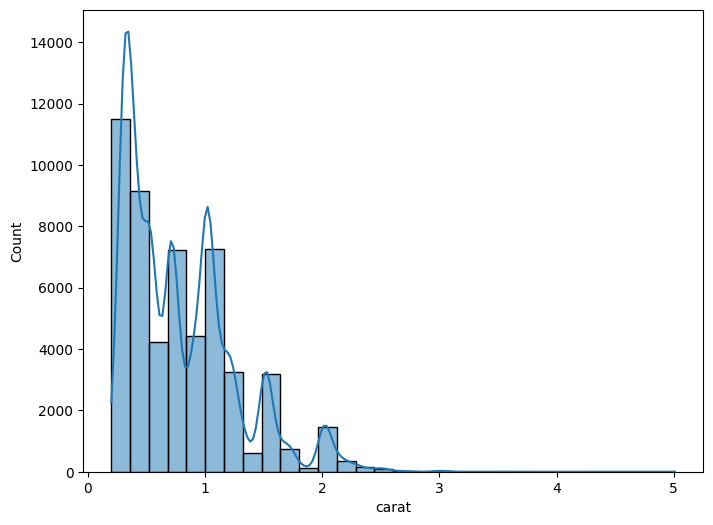

In [15]:
plt.figure(figsize=[8, 6])

sns.histplot(data=df, x='carat', bins=30, kde=True)

plt.show();


## Задание 6

Ответьте на несколько вопросов по данным:
* Сколько карат весит самый тяжелый бриллиант в датасете? А самый легкий?
* Сколько мелких бриллиантов в датасете?
* Сколько процентов бриллиантов среди всего датасета - крупные?

In [16]:
df.iloc[[df['carat'].idxmax()]]


,carat,cut,color,clarity,depth,table,price,'x','y','z'
27355,5.01,Fair,J,I1,65.5,59.0,18018.0,10.74,10.54,6.98


In [17]:
df.iloc[[df['carat'].idxmin()]]

,carat,cut,color,clarity,depth,table,price,'x','y','z'
14,0.2,Premium,E,SI2,60.2,62.0,345.0,3.79,3.75,2.27


In [18]:
len(df[df['carat'] < 0.3])

1582

In [19]:
df['carat_size'] = pd.cut(x=df['carat'], bins=[-np.inf, 0.3, 1, np.inf], labels=['Small', 'Medium', 'Large'], right=False)

In [20]:
(df['carat_size'] == 'Small').sum()

1582

In [21]:
df['carat_size'].value_counts(normalize=True).round(2)

carat_size
Medium    0.62
Large     0.35
Small     0.03
Name: proportion, dtype: float64

## Задание 7

Посмотрите как число карат влияет на стоимость бриллианта. Для этого:

1. Постройте диаграмму рассеяния (scatter plot) для оценки взаимосвязи столбцов `carat` и `price`

2. Вычислите коэффициент корреляции Пирсона между столбцами `carat` и `price`.

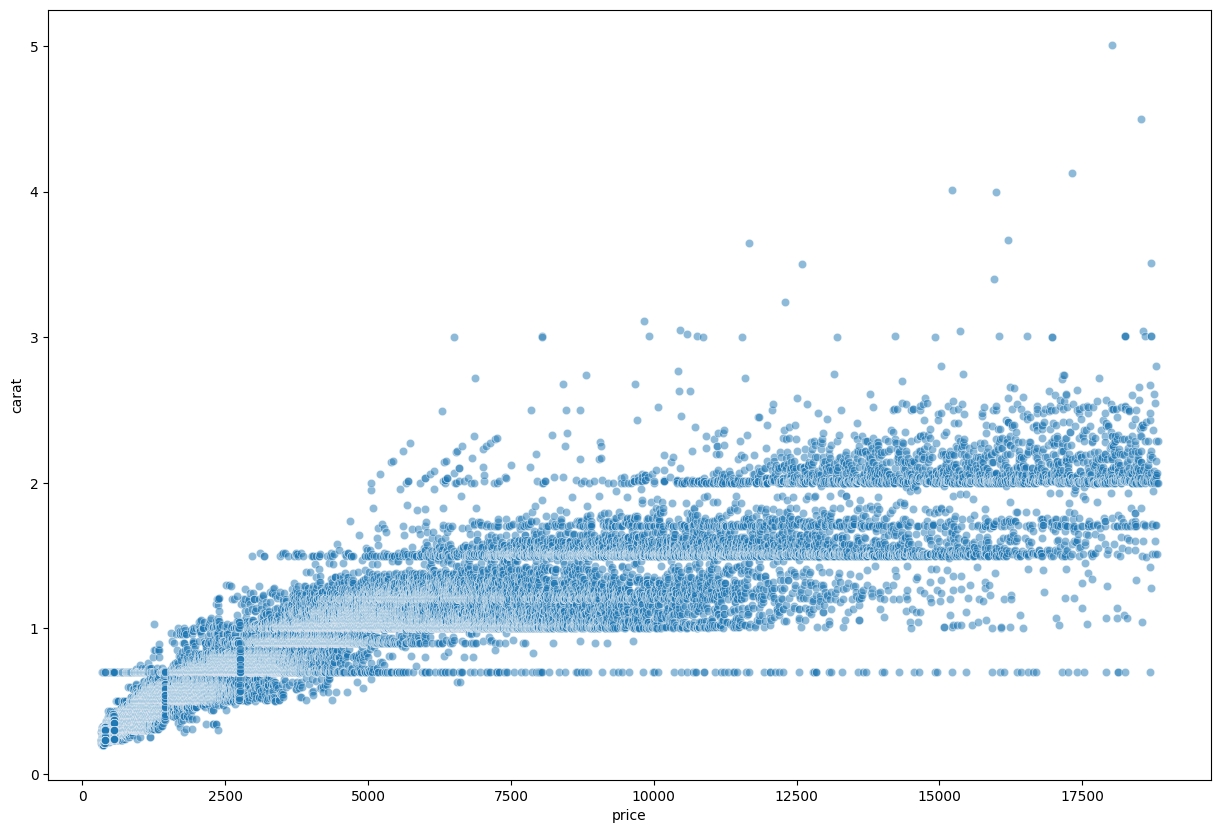

In [22]:
plt.figure(figsize=[15, 10])

sns.scatterplot(data=df, x=df['price'], y=df['carat'], alpha=0.5)

plt.show();

In [23]:
df['carat'].corr(df['price'])

0.9164989435440221

### Cut (огранка бриллианта)

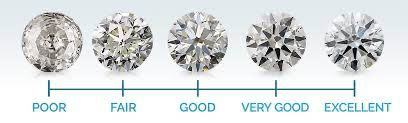

In [24]:
df['cut'].value_counts(normalize=True)

cut
Ideal        0.398941
Premium      0.255088
Very Good    0.224013
Good         0.090772
Fair         0.029700
Goood        0.001487
Name: proportion, dtype: float64

In [25]:
df['cut'] = df['cut'].replace('Goood', 'Good')

Посмотрим как влияет огранка бриллианта на его стоимость

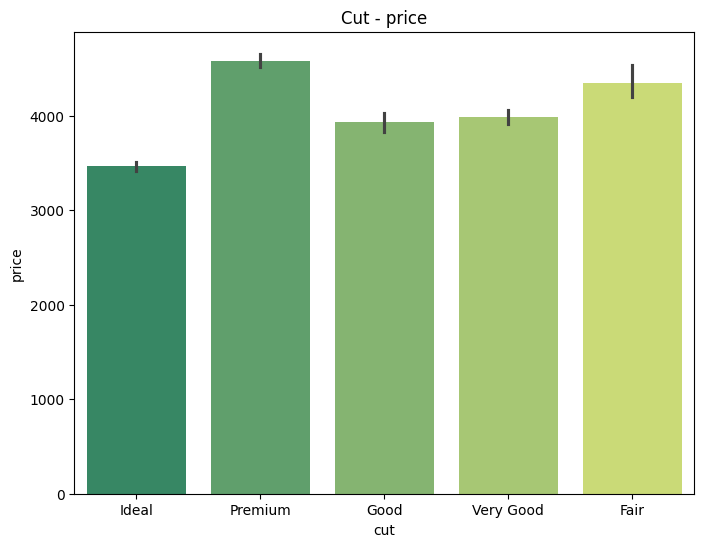

In [26]:
plt.figure(figsize=(8,6))

sns.barplot(data=df, x='cut', y='price', hue='cut', palette='summer')
plt.title('Cut - price')

plt.show();

## Задание 8

Ответьте на следующие вопросы по данным:
* Какое максимальное число карат весит бриллиант огранки `Fair`?
* Вычислите среднюю стоимость бриллианта в каждой категории столбца `cut`

In [27]:
df[df['cut']=='Fair']['carat'].max()

5.01

In [28]:
df.groupby('cut').agg({'price':'mean'}).round().reset_index()

,cut,price
0,Fair,4348.0
1,Good,3926.0
2,Ideal,3463.0
3,Premium,4582.0
4,Very Good,3982.0


## Table and Depth

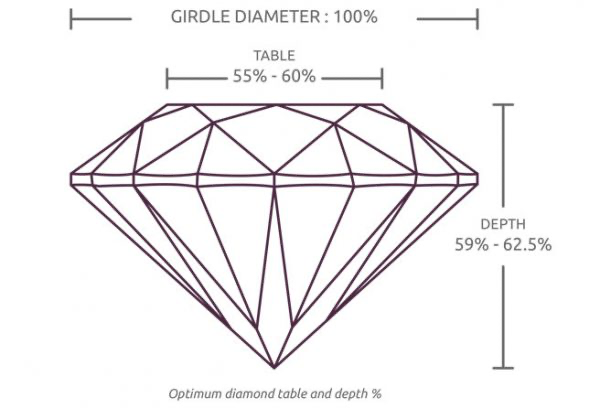

## Задание 9

Оптимальное значение параметра `table` для бриллианта [55%; 60%].

Какая доля бриллиантов в данных имеют оптимальное значение `table`?

In [29]:
mask = (55 <= df['table']) & (df['table'] <= 60)
round(len(df[mask]) / len(df), 2)

0.84

In [30]:
df['table'].between(55, 60).mean().round(2)

0.84

## Задание 10

Оптимальное значение параметра `depth` для алмаза [59%; 62.5%].

Какая доля бриллиантов в данных имеют одновременно оптимальное значение `table` и `depth`?

In [31]:
(df['table'].between(55, 60) & df['depth'].between(59, 62.5)).mean().round(2)

0.62

## Задание 11

Сравните медианную стоимость всех бриллиантов и бриллиантов с оптимальными table & depth. Какая больше?

In [32]:
mask = (55 <= df['table']) & (df['table'] <= 60) & (
    (59 <= df['depth']) & (df['depth'] <= 62.5))

df['price'].median() > df[mask]['price'].median()

True

## Задание 12

Вычислите корреляцию `table` и `price`, а затем `depth`и `price`. Какой параметр влияет на цену больше?

In [33]:
df['table'].corr(df['price'])

0.12662153885758198

In [34]:
df['depth'].corr(df['price'])

-0.010831614226837231

## Clarity - прозрачность бриллианта

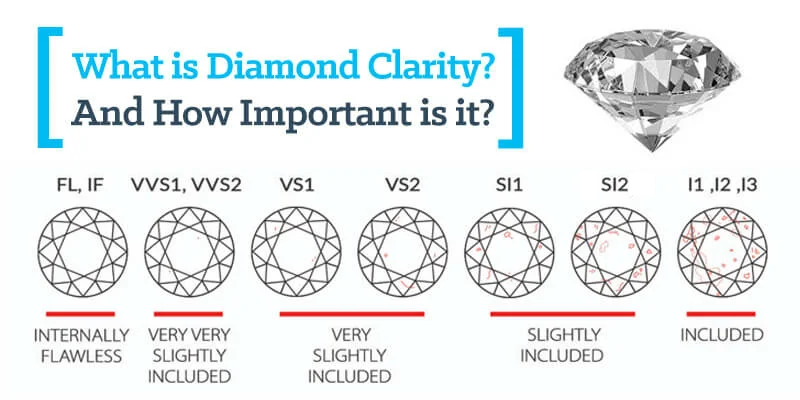

## Задание 13

Сколько различных градаций есть в столбце `clarity`?

In [35]:
df['clarity'].nunique()

8

## Задание 14

Сколько бриллиантов в таблице, относящихся к категории `very very slightly included`?

In [36]:
(df['clarity'].isin(['VVS2', 'VVS1'])).sum()

8704

## Задание 15

Нарисуйте график зависимости цены бриллиантов от `clarity`. Бриллианты какой категории в наших данных стоят дороже остальных?

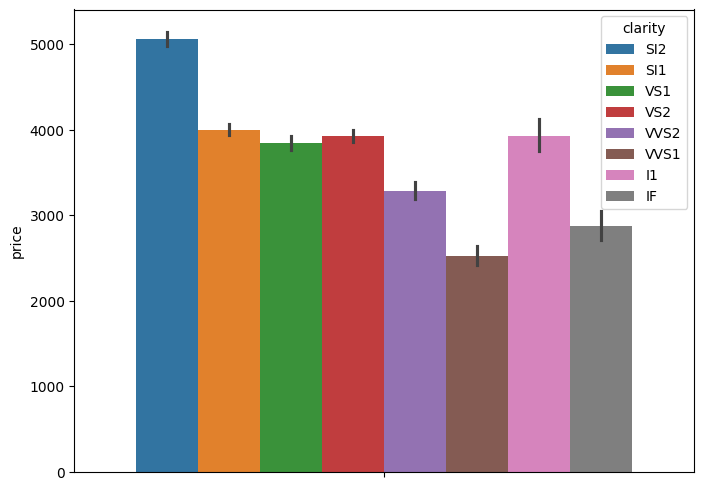

In [37]:
plt.figure(figsize=[8, 6])

sns.barplot(data=df, y='price', hue='clarity')

plt.show();

## Задание 16

Для каждой пары значений категорий (`cut`,`clarity`) вычислим среднюю и медианную стоимость. Результат отсортируем по убыванию средней стоимости.

Бриллианты какой огранки (`cut`) в совокупностью с некоторой категорией `clarity` имеют наибольшую среднюю стоимость?

In [ ]:
df.groupby(['cut', 'clarity'])['price'].agg(['mean', 'median']) \
    .reset_index().sort_values('mean', ascending=False, ignore_index=True).head()

,cut,clarity,mean,median
0,Premium,SI2,5556.262491,4292.5
1,Fair,SI2,5145.740175,3681.0
2,Very Good,SI2,4988.709447,4042.0
3,Ideal,SI2,4761.711917,4068.0
4,Good,SI2,4544.119816,3763.0


## Признаки x, y, z

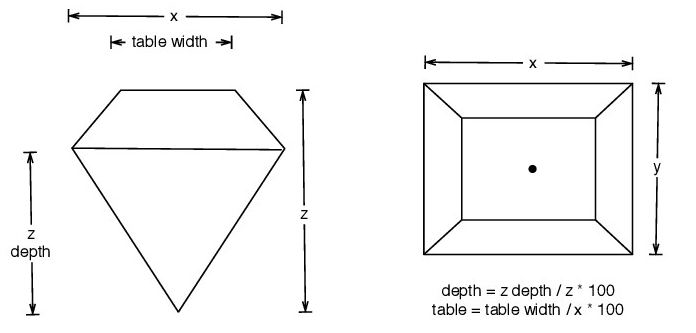

In [39]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', ''x'',
       ''y'', ''z'', 'carat_size'],
      dtype='str')

Переименуем колонки

In [40]:
df = df.rename(columns={"'x'" : 'x', "'y'" : 'y', "'z'" : 'z'})
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z', 'carat_size'],
      dtype='str')

## Задание 17

Для каждого из трех столбцов (`x`, `y`, `z`) вычислите:
* медианное значение
* минимальное значение

In [45]:
df[['x', 'y', 'z']].describe().T.loc[:, ['50%', 'mean']]

,50%,mean
x,5.70,5.731325
y,5.71,5.734700
z,3.53,3.538800


## Задание 18

Выведите на экран все строки таблицы (только столбцы `x`,`y`,`z`), в которых хотя бы одна из координат равна нулю.

Сколько таких строк?

In [59]:
cols = ['x', 'y', 'z']
mask = (df[cols] == 0).any(axis=1)

df.loc[mask, cols].reset_index()

,index,x,y,z
0,2201,6.55,6.48,0.0
1,2308,6.66,6.60,0.0
2,4779,6.50,6.47,0.0
3,5458,6.50,6.47,0.0
4,10146,7.15,7.04,0.0
5,11158,0.00,6.62,0.0
6,11937,0.00,0.00,0.0
7,13572,6.88,6.83,0.0
8,15916,0.00,0.00,0.0
9,24342,8.49,8.45,0.0


## Задание 19

Удалите из таблицы эти строки. Сколько строк осталось в таблице?

In [61]:
df = df[~mask]
df.shape

(53786, 11)

## Задание 20

Вычислите корреляцию между каждым из этих столбцов и `price`. Какой столбец коррелирует с ценой бриллианта больше всего?

In [63]:
cols = ['x', 'y', 'z']

for col in cols:
    print(col, round(df[col].corr(df['price']), 4))

x 0.8872
y 0.8677
z 0.8681


## Задание 21

Постройте scatter plot для отражения зависимости между ценой бриллианта и координатой, наиболее с ней коррелирующей. На какую зависимость она больше всего похожа?

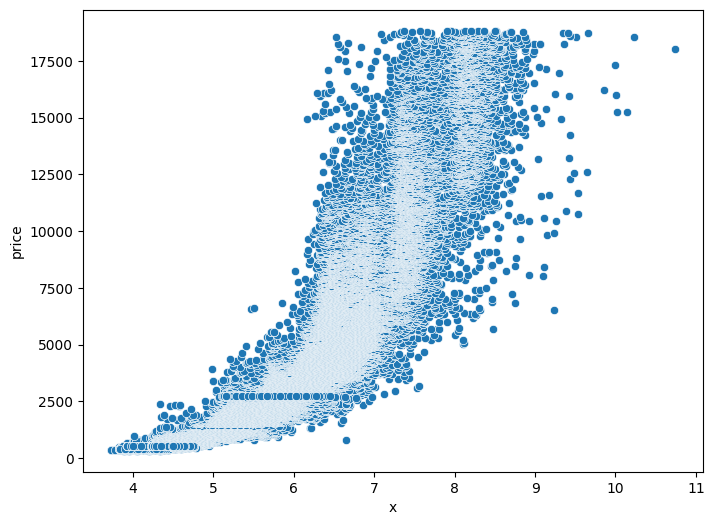

In [64]:
plt.figure(figsize=[8, 6])

sns.scatterplot(data=df, x='x', y='price')

plt.show();

## Задание 22

Какой процент среди всех бриллиантов имеет `x` и `y` размеры, превышающие средние значения (по `x` и `y`)? Ответ округлите до целого числа.

In [66]:
x_mean = df['x'].mean()
y_mean = df['y'].mean()

len(df[(df['x'] > x_mean) & (df['y'] > y_mean)]) / len(df)

0.473784999814078

## Задание 23

Какая доля среди крупных бриллиантов имеет `z`-размеры, меньшие медианного по всем бриллиантам? Ответ округлите до четырех знаков после запятой.

In [68]:
z_meadian = df['z'].median()

round(len(df[(df['carat_size'] == 'Large') & (df['z'] < z_meadian)]) / len(df[df['carat_size'] == 'Large']), 4)

0.0002

## Признак `Color`

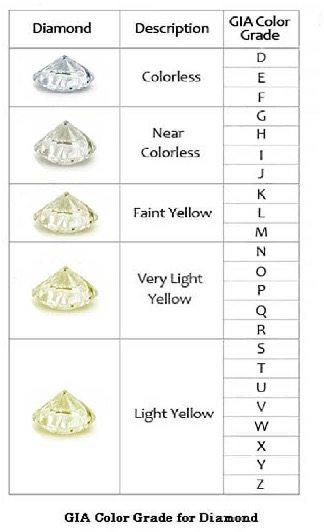

## Задание 24

К каким категориям (Description) из градации выше относятся бриллианты в данных?

In [74]:
np.sort(df['color'].unique())

array(['D', 'E', 'F', 'G', 'H', 'I', 'J'], dtype=object)

In [75]:
def get_description(color):
    if color in ['D', 'E', 'F']:
        return 'Colorless'
    elif color in ['G', 'H', 'I', 'J']:
        return 'Near Colorless'

In [76]:
df['color_description'] = df['color'].apply(get_description)

In [77]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,carat_size,color_description
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43,Small,Colorless
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31,Small,Colorless
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31,Small,Colorless
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63,Small,Near Colorless
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75,Medium,Near Colorless


## Задание 25

Нарисуйте график, отражающий зависимость стоимости бриллианта от его категории цвета.

Бриллианты какого цвета стоят дороже остальных?

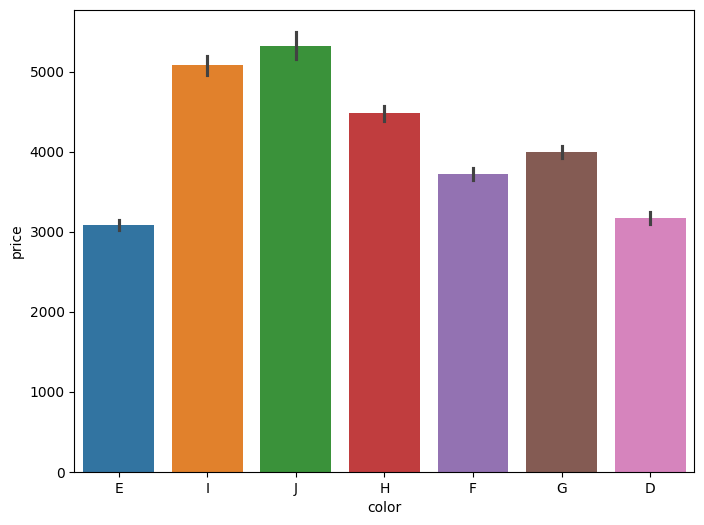

In [78]:
plt.figure(figsize=[8, 6])

sns.barplot(data=df, x='color', y='price', hue='color')

plt.show();

## Задание 26

Для каждого цвета бриллианта вычислите медианную стоимость и медианный вес (в каратах). Отсортируйте полученную при помощи groupby таблицу по убыванию медианной стоимости.

Верно ли, что при убывании PriceMedian, сгруппированной по цвету, CaratMedian также убывает? (не возрастает)

In [90]:
df.groupby('color')[['price', 'carat']].agg({'price': 'median', 'carat': 'median'}) \
    .reset_index().sort_values('price', ascending=False, ignore_index=True)

,color,price,carat
0,J,4234.5,1.11
1,I,3721.5,1.00
2,H,3449.5,0.90
3,F,2345.0,0.70
4,G,2242.0,0.70
5,D,1842.0,0.54
6,E,1741.0,0.54


## Задание 27

Вычислите среднюю стоимость бриллиантов по каждой тройке категорий (`cut`,`color`,`clarity`). Какие бриллианты дороже остальных?

В ответе запишите тройку названий в скобках через запятую, без кавычек и пробелов. Например, (Premium,D,IF)

In [99]:
df.groupby(['cut', 'color', 'clarity'])[['price']].agg({'price': 'mean'}) \
    .reset_index().sort_values('price', ascending=False, ignore_index=True).head()

,cut,color,clarity,price
0,Very Good,D,IF,10298.260870
1,Good,D,IF,10030.333333
2,Ideal,J,I1,9454.000000
3,Premium,D,IF,9056.500000
4,Premium,J,SI2,7550.285714
